<a href="https://colab.research.google.com/github/Abhishekbelwal/Machine-Learning-basic-algorithms-and-projects/blob/main/SupportVectoreRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Support Vector Regression (SVR)

**Definition:** Support Vector Regression (SVR) is a type of Support Vector Machine (SVM) that is used for regression tasks. Unlike traditional regression models that try to minimize the error between predictions and actual values, SVR tries to fit the best line within a margin of tolerance (epsilon) around the predicted values. It focuses on finding a function that has at most ε deviation from the training data for all training data, and at the same time is as flat as possible.

**Uses:**
*   **Time Series Forecasting:** Predicting future values based on historical data.
*   **Financial Forecasting:** Predicting stock prices or market trends.
*   **Demand Forecasting:** Estimating future demand for products or services.
*   **Environmental Modeling:** Predicting pollution levels or climate changes.
*   **Non-linear Regression:** When the relationship between input and output variables is not linear.

**Types of Kernels (for handling non-linear relationships):**
*   **Linear:** Suitable for linearly separable data. It's the simplest kernel.
    *   `kernel='linear'`
*   **Polynomial:** Useful for problems where the decision boundary is a polynomial curve.
    *   `kernel='poly'`
*   **Radial Basis Function (RBF) / Gaussian:** A popular choice for non-linear data, especially when there's no prior knowledge about the data.
    *   `kernel='rbf'` (This is often the default)
*   **Sigmoid:** Used in neural networks as an activation function, and can also be used as an SVR kernel.
    *   `kernel='sigmoid'`

**Example (as seen in the code):**

```python
regressor = SVR(kernel='rbf') # Using the Radial Basis Function kernel
regressor.fit(x_std, y_std)
```

SVR aims to find a function that best describes the relationship between `x` and `y` while staying within an acceptable error margin, making it robust to outliers and effective for various regression problems.

In [6]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
x=np.array([[1],[2],[3],[4],[5],[6]])
y=np.array([1.4,1.6,1.4,1.8,4.4,5.6])
sc_x=StandardScaler()
sc_y=StandardScaler()
x_std=sc_x.fit_transform(x)
y_std=sc_y.fit_transform(y.reshape(-1,1))
regressor=SVR(kernel='rbf')
regressor.fit(x_std,y_std)
y_pred=regressor.predict(x_std)
print(r2_score(y_std,y_pred))


0.9589668120271396


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


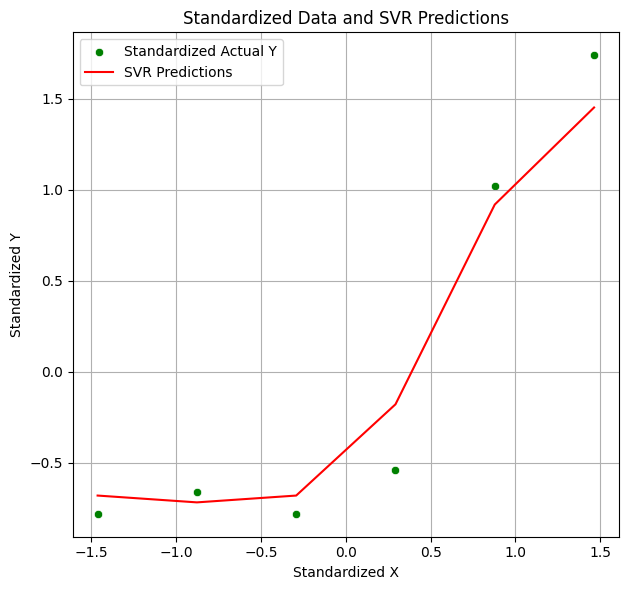

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_original_scale = sc_y.inverse_transform(y_pred.reshape(-1, 1))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 2)
sns.scatterplot(x=x_std.flatten(), y=y_std.flatten(), color='green', label='Standardized Actual Y')
sns.lineplot(x=x_std.flatten(), y=y_pred, color='red', label='SVR Predictions')
plt.title('Standardized Data and SVR Predictions')
plt.xlabel('Standardized X')
plt.ylabel('Standardized Y')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()